# ISH and WRF-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare WRF-CHEM results against ISH surface observations for temperature, wind speed, and dewpoint.

ISH is a particularly useful for model evaluations because it is a global dataset. As you will see in the YAML file, we can create plots globally, for individual countries, and states. NOTE: MELODIES-MONET examples that use ISH will take longer to finish running due to the larger amount of data.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ish_wrfchem-example_withT2.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2023-08-01-00:00:00',
  'end_time': '2023-08-04-00:00:00',
  'output_dir': './output/ish_wrfchem_restructure',
  'debug': True},
 'model': {'wrfchem': {'files': '/wrk/d2/rschwantes/wrf/output_w_3hr_raqms_fire_correct/*',
   'mod_type': 'wrfchem',
   'mod_kwargs': {'mech': 'racm_esrl_vcp', 'surf_only': True},
   'radius_of_influence': 12000,
   'extra_calc': {'wind_barb': {'u_comp': 'uvmet10_u', 'v_comp': 'uvmet10_v'},
    'rose_plot': {'model_wdir': 'uvmet10_wdir', 'model_wspd': 'uvmet10_wspd'}},
   'variables': {'td2': {'unit_scale': 273.15, 'unit_scale_method': '+'}},
   'mapping': {'ish': {'uvmet10_wspd': 'ws', 'T2': 't', 'td2': 'dpt'}},
   'projection': None,
   'plot_kwargs': {'color': 'magenta', 'marker': 's', 'linestyle': '-'}}},
 'obs': {'ish': {'filename': '/wrk/d2/rschwantes/obs/ISH/ISH_20230801_20230901.nc',
   'obs_type': 'pt_sfc',
   'variables': {'t': {'unit_scale': 273.15,
     'unit_scale_method': '+',
     'nan_value': -1.0,
     'ylabel_pl

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ish_wrfchem-example_withT2.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2023-08-01 00:00:00'),
    end_time=Timestamp('2023-08-04 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/ish_wrfchem_restructure',
    output_dir_save='./output/ish_wrfchem_restructure',
    output_dir_read='./output/ish_wrfchem_restructure',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

wrfchem
/wrk/d2/rschwantes/wrf/output_w_3hr_raqms_fire_correct/*
**** Reading WRF-Chem model output...
Performing extra model calculations...
No extra calculations performed.


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

In [7]:
an.models

{'wrfchem': model(
     model='wrfchem',
     is_global=False,
     radius_of_influence=12000,
     mod_kwargs={'mech': 'racm_esrl_vcp', 'surf_only': True, 'var_list': ['td2', 'T2', 'uvmet10', 'uvmet10_wspd_wdir', 'pres', 'height', 'tk', 'height_agl', 'PSFC', 'zstag']},
     file_str='/wrk/d2/rschwantes/wrf/output_w_3hr_raqms_fire_correct/*',
     label='wrfchem',
     obj=...,
     extra_calc={'wind_barb': {'u_comp': 'uvmet10_u', 'v_comp': 'uvmet10_v'}, 'rose_plot': {'model_wdir': 'uvmet10_wdir', 'model_wspd': 'uvmet10_wspd'}},
     mapping={'ish': {'uvmet10_wspd': 'ws', 'T2': 't', 'td2': 'dpt'}},
     variable_dict={'td2': {'unit_scale': 273.15, 'unit_scale_method': '+'}, 'uvmet10_u': 'None', 'uvmet10_v': 'None', 'uvmet10_wdir': 'None', 'uvmet10_wspd': 'None'},
     label='wrfchem',
     ...
 )}

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [8]:
an.models['wrfchem'].obj

<xarray.Dataset> Size: 3GB
Dimensions:        (y: 284, x: 440, time: 96, z: 1, bottom_top_stag: 51)
Coordinates:
    longitude      (y, x) float32 500kB -122.3 -122.2 -122.1 ... -60.52 -60.37
    latitude       (y, x) float32 500kB 21.19 21.22 21.24 ... 50.28 50.24 50.2
  * time           (time) datetime64[ns] 768B 2023-08-01 ... 2023-08-04T23:00:00
Dimensions without coordinates: y, x, z, bottom_top_stag
Data variables: (12/13)
    td2            (time, z, y, x) float32 48MB 294.2 294.2 ... 288.4 287.6
    T2             (time, z, y, x) float32 48MB 296.2 296.2 ... 289.7 288.7
    uvmet10_u      (time, z, y, x) float32 48MB -0.8349 -0.8181 ... -1.36 -1.515
    uvmet10_v      (time, z, y, x) float32 48MB -2.552 -2.504 ... 3.575 3.507
    uvmet10_wspd   (time, z, y, x) float32 48MB 2.685 2.634 2.59 ... 3.825 3.82
    uvmet10_wdir   (time, z, y, x) float32 48MB 18.12 18.09 ... 159.2 156.6
    ...             ...
    alt_msl_m_mid  (time, z, y, x) float32 48MB 11.35 11.35 11.35 ... 17.1 13.28
    temperature_k  (time, z, y, x) float32 48MB 296.1 296.1 ... 289.5 288.5
    alt_agl_m_mid  (time, z, y, x) float32 48MB 11.36 11.36 ... 11.05 11.01
    surfpres_pa    (time, z, y, x) float32 48MB 1.014e+05 ... 1.021e+05
    zstag          (time, z, bottom_top_stag, y, x) float32 2GB -0.009976 ......
    dz_m           (time, z, y, x) float32 48MB 22.72 22.72 ... 22.11 22.02
Attributes: (12/15)
    FieldType:                 104
    MemoryOrder:               XY 
    description:               2m dew point temperature
    units:                     degC
    stagger:                   
    coordinates:               XLONG XLAT XTIME
    ...                        ...
    MOAD_CEN_LAT:              39.617638
    STAND_LON:                 -97.0
    MAP_PROJ:                  1
    CEN_LAT:                   39.617638
    CEN_LON:                   -97.77487
    mapping_tables_to_airnow:  {'OZONE': 'o3', 'PM2.5': 'PM2_5_DRY', 'PM10': ...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [9]:
an.open_obs()

Performing extra calculations for obs...
No extra calculations performed.


In [10]:
an.obs

{'ish': observation(
     obs='ish',
     label='ish',
     file='/wrk/d2/rschwantes/obs/ISH/ISH_20230801_20230901.nc',
     obj=...,
     extra_calc={'rose_plot': {'obs_wdir': 'wdir', 'obs_wspd': 'ws'}},
     type='pt_src',
     sat_type=None,
     sat_method=None,
     data_proc=None,
     variable_dict={'t': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 5.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 12, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 20, 'nlevels_plot': 18}, 'dpt': {'unit_scale': 273.15, 'unit_scale_

In [11]:
an.obs['ish']

observation(
    obs='ish',
    label='ish',
    file='/wrk/d2/rschwantes/obs/ISH/ISH_20230801_20230901.nc',
    obj=...,
    extra_calc={'rose_plot': {'obs_wdir': 'wdir', 'obs_wspd': 'ws'}},
    type='pt_src',
    sat_type=None,
    sat_method=None,
    data_proc=None,
    variable_dict={'t': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 5.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 12, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 20, 'nlevels_plot': 18}, 'dpt': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [12]:
%%time

an.pair_data()

1, in pair data
After pairing:                time  varlength  wdir   ws  ceiling  vsb       t     dpt  \
0       2023-08-01       96.0  25.0  0.0      NaN  NaN  279.15  279.15   
1       2023-08-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
2       2023-08-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
3       2023-08-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
4       2023-08-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
...            ...        ...   ...  ...      ...  ...     ...     ...   
9523330 2023-09-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
9523331 2023-09-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
9523332 2023-09-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
9523333 2023-09-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   
9523334 2023-09-01        NaN   NaN  NaN      NaN  NaN     NaN     NaN   

              p       siteid  ...  utcoffset      begin        end  \
0        

In [13]:
an.paired

{'ish_wrfchem': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='ish',
     model='wrfchem',
     model_vars=['uvmet10_wspd', 'T2', 'td2'],
     obs_vars=['ws', 't', 'dpt'],
     filename='ish_wrfchem.nc',
 )}

In [14]:
an.paired['ish_wrfchem']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='ish',
    model='wrfchem',
    model_vars=['uvmet10_wspd', 'T2', 'td2'],
    obs_vars=['ws', 't', 'dpt'],
    filename='ish_wrfchem.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated at the Country-, EPA region-, and MSA-scale 
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

**NOTE:** That ISH data for calm wind sets windspeed = 0 and wind direction = 0. In the wind-rose plots, calm winds are plotted as an inner circle for wind direction and data is removed for pollution rose plots based on the threshold set in your yaml file. 

All other plots, it's up to the user on what to consider for these calm winds. Plots below and corresponding yaml file demonstrates how to remove all calm winds from the calculation for the timeseries plots (second set of plots plot_grp1a) and the spatial overlay plots (second set of plots plot_grp3a). You can see that windspeed biases go down when removing these calm winds. Additional processing and consideration for calm winds is under development.

Saving rose plot to ./output/ish_wrfchem_restructure/plot_grp6.rose_plot.ws.2023-08-01_00.2023-08-04_00.state.CA...


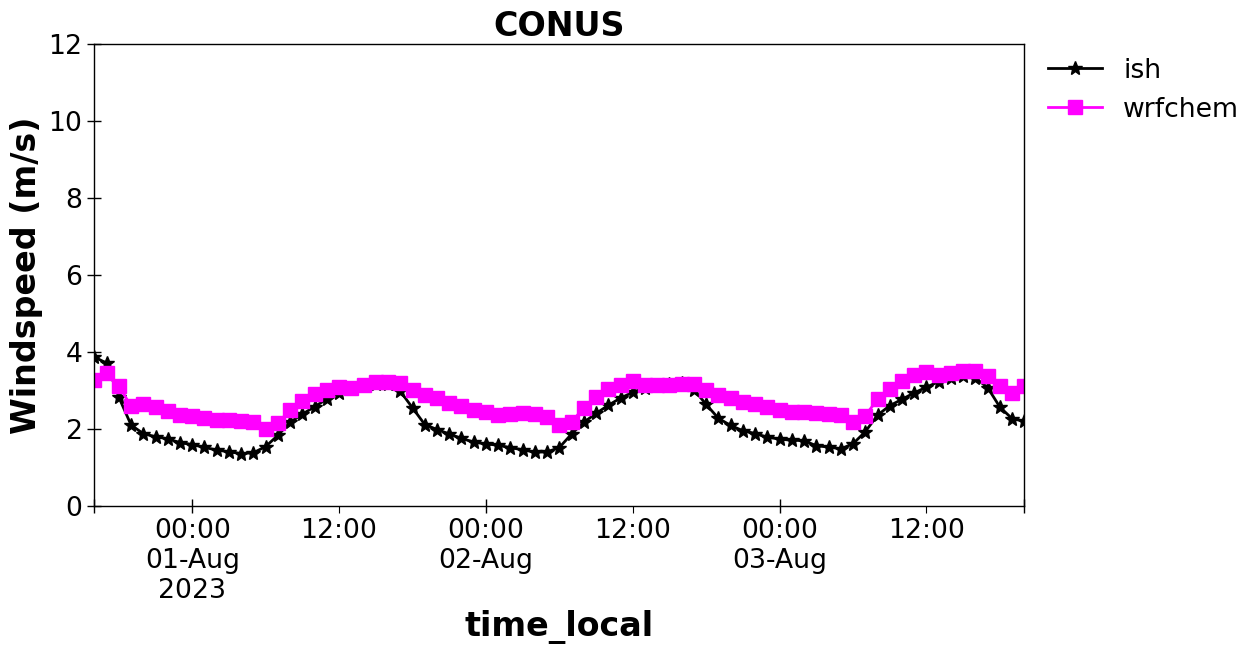

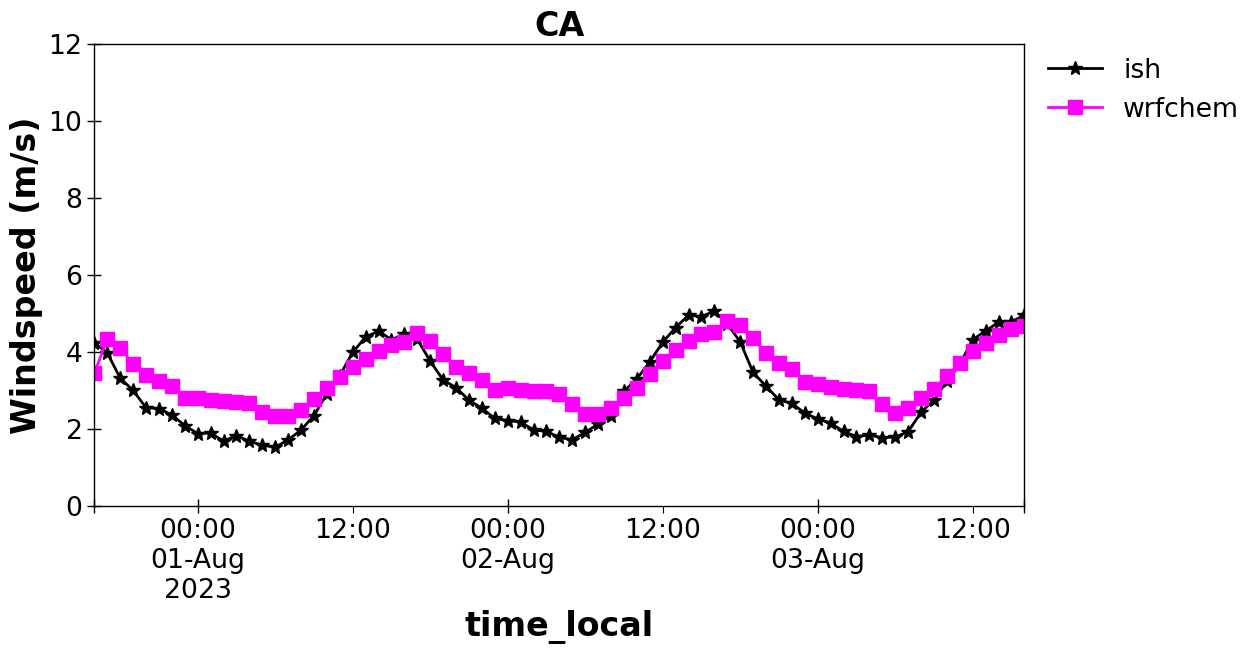

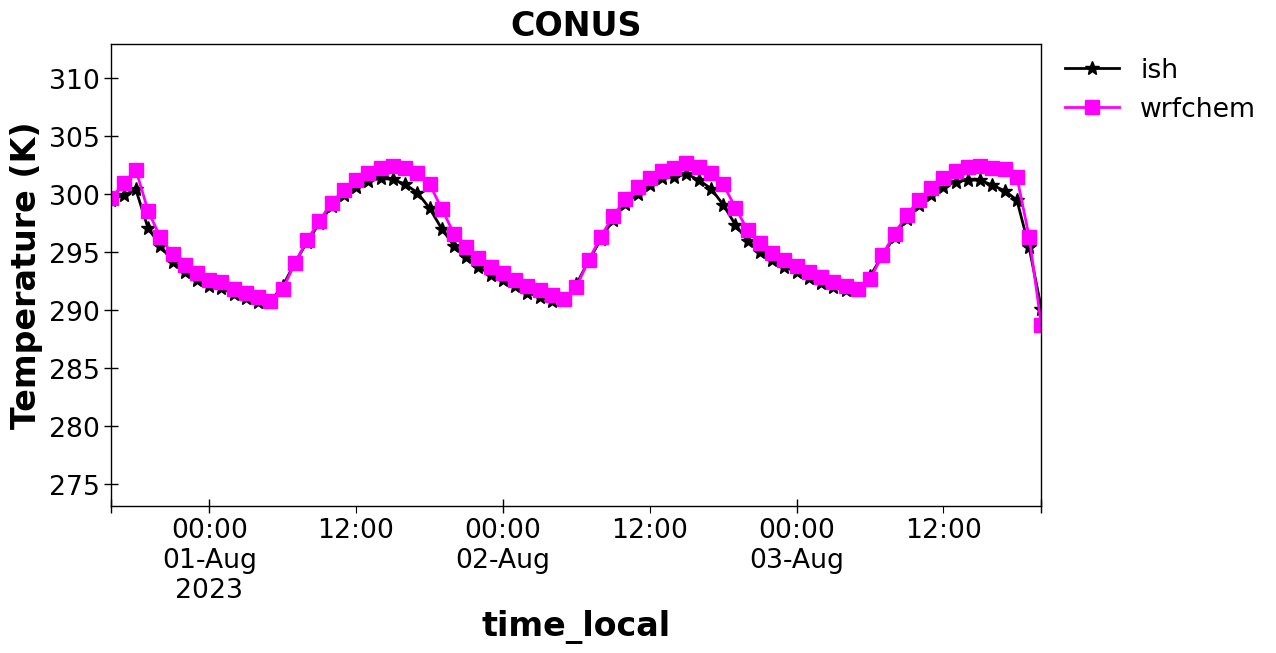

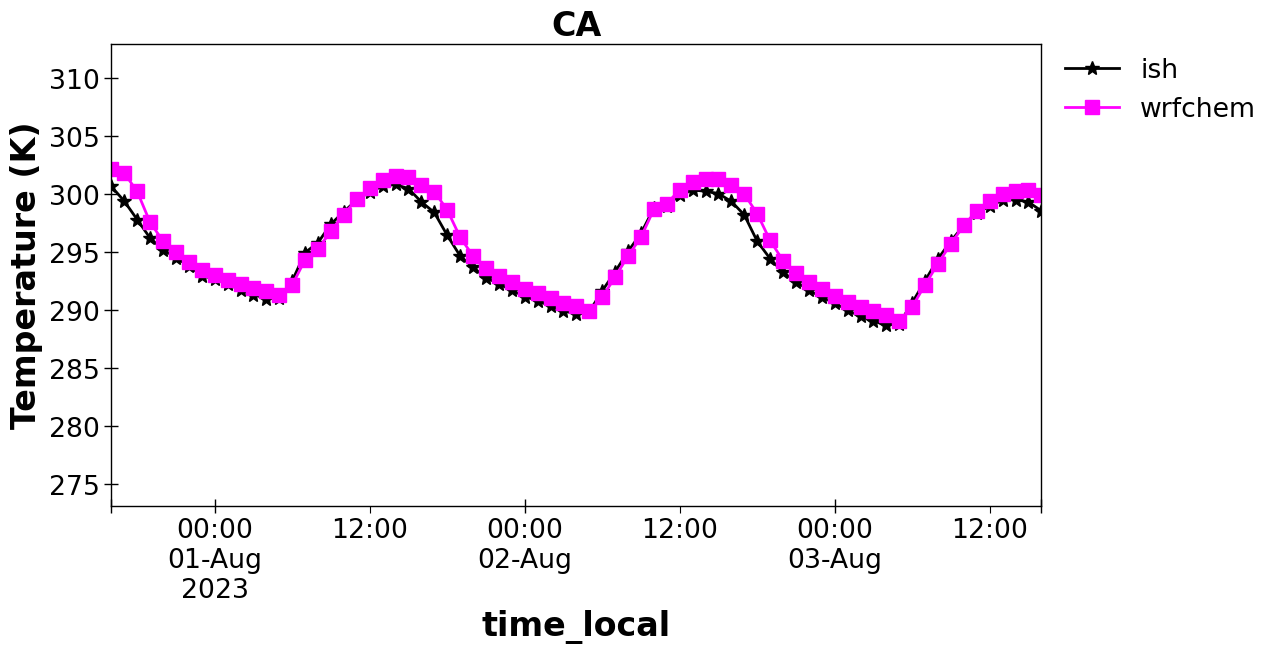

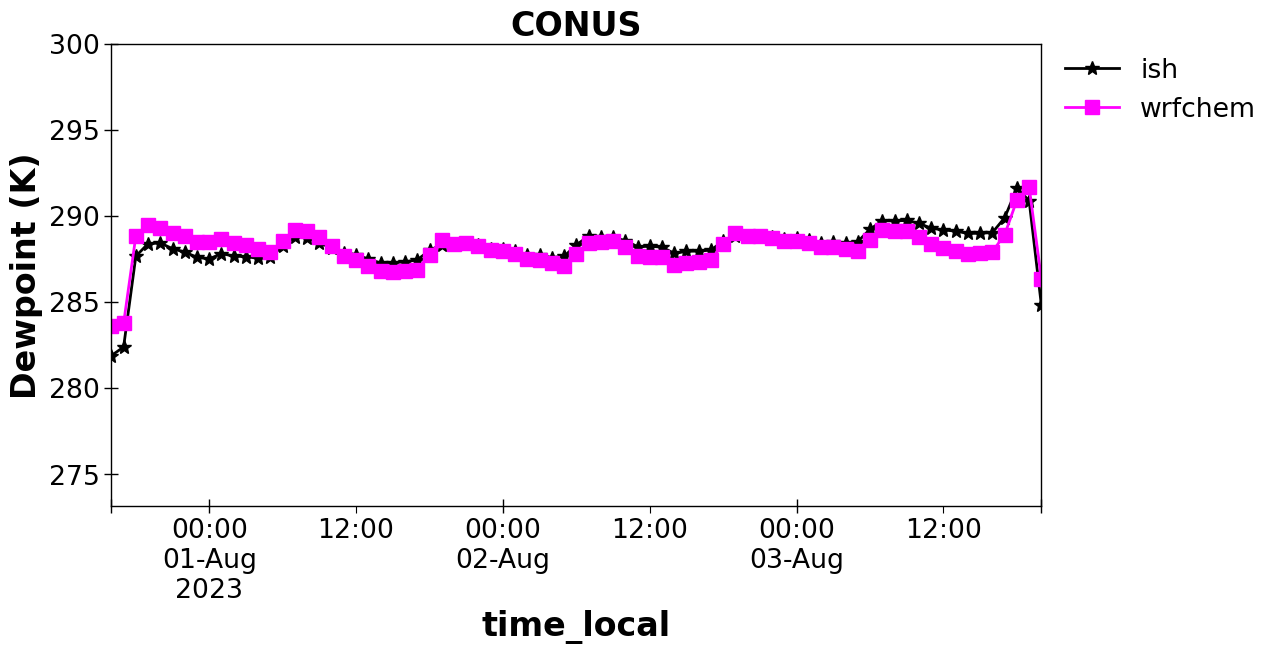

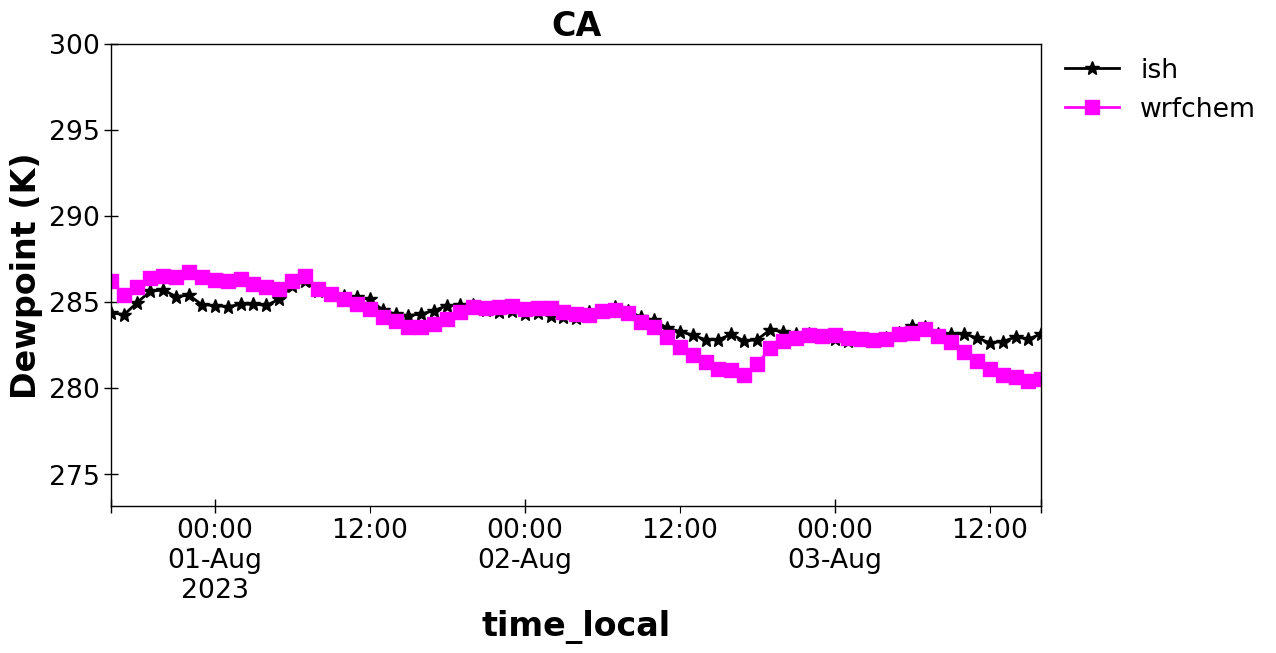

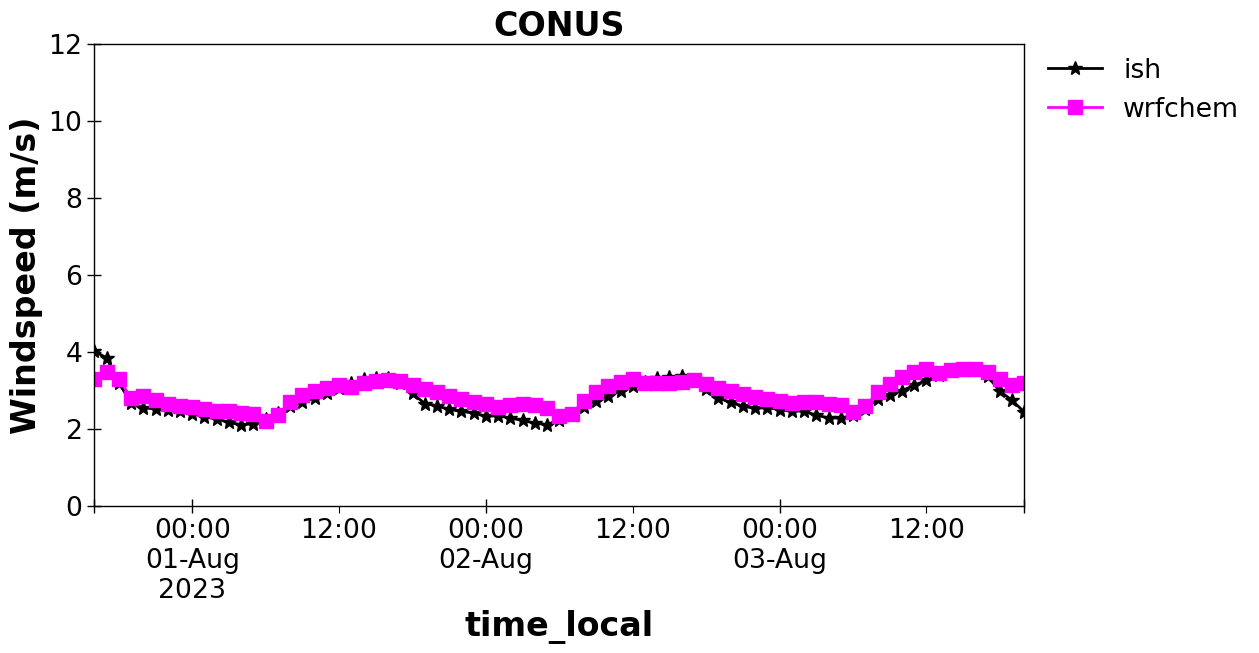

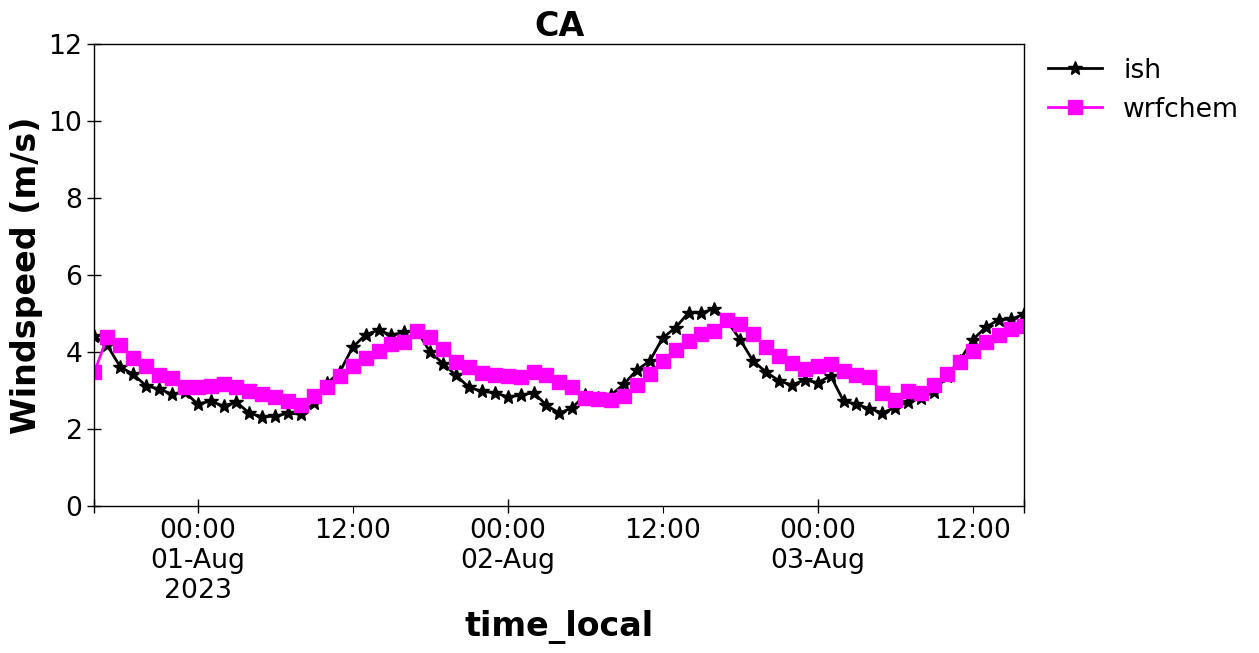

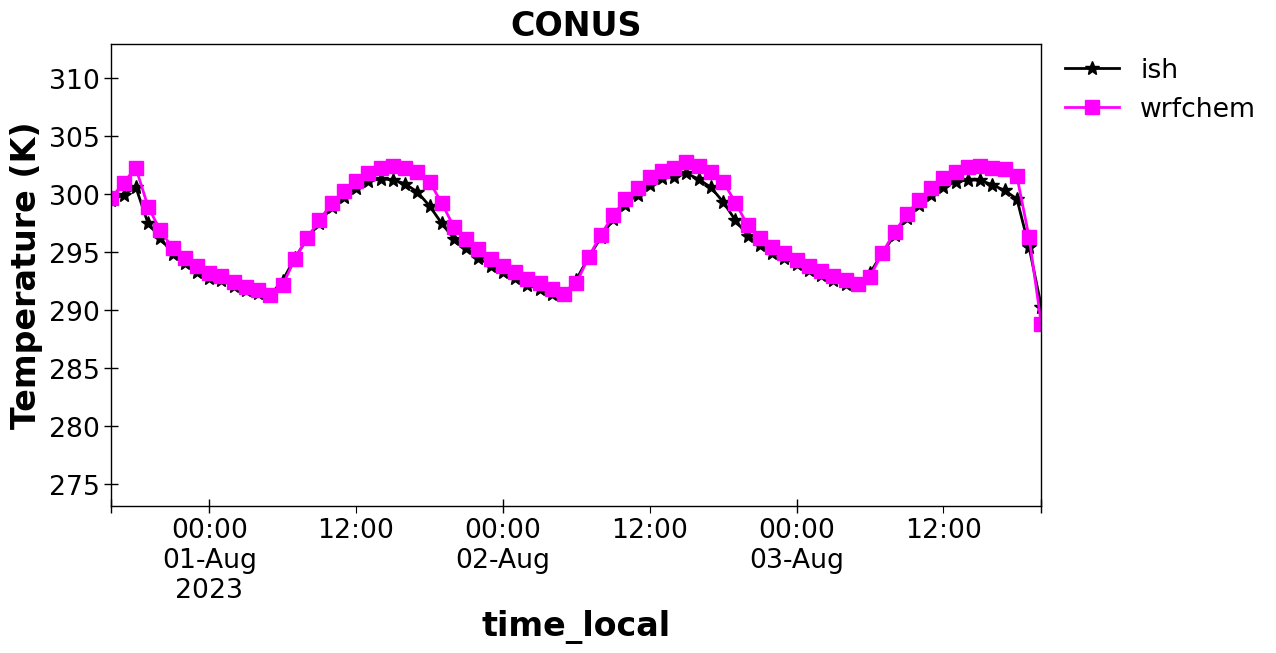

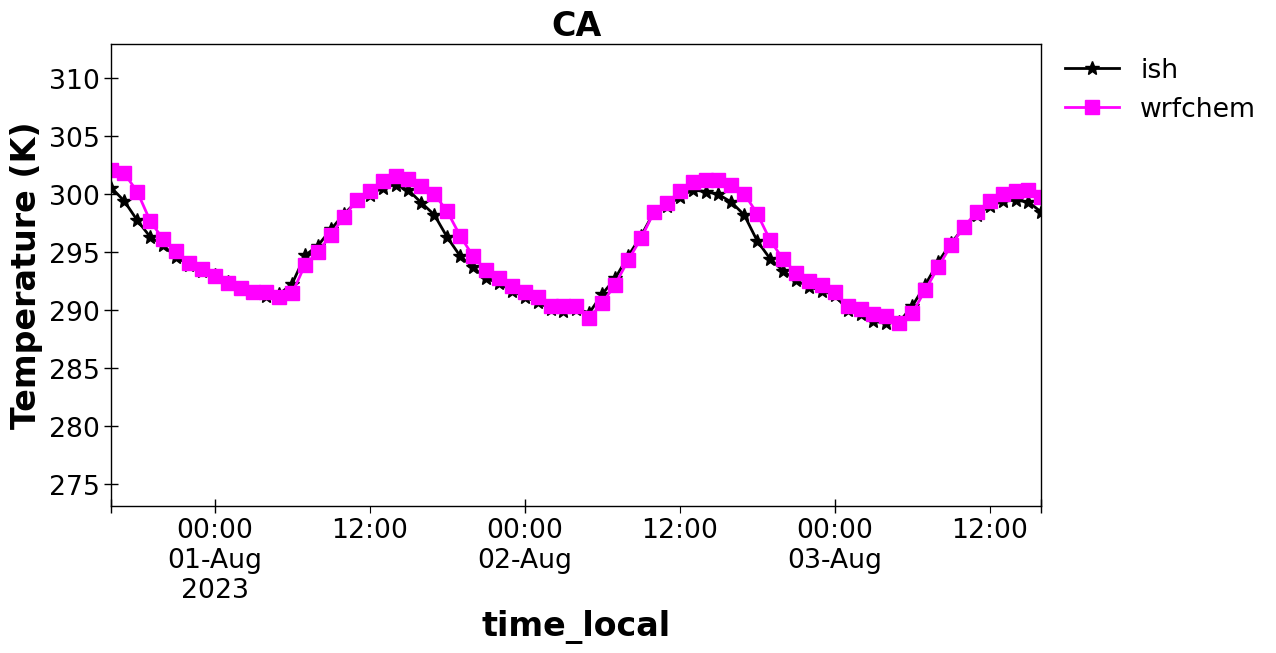

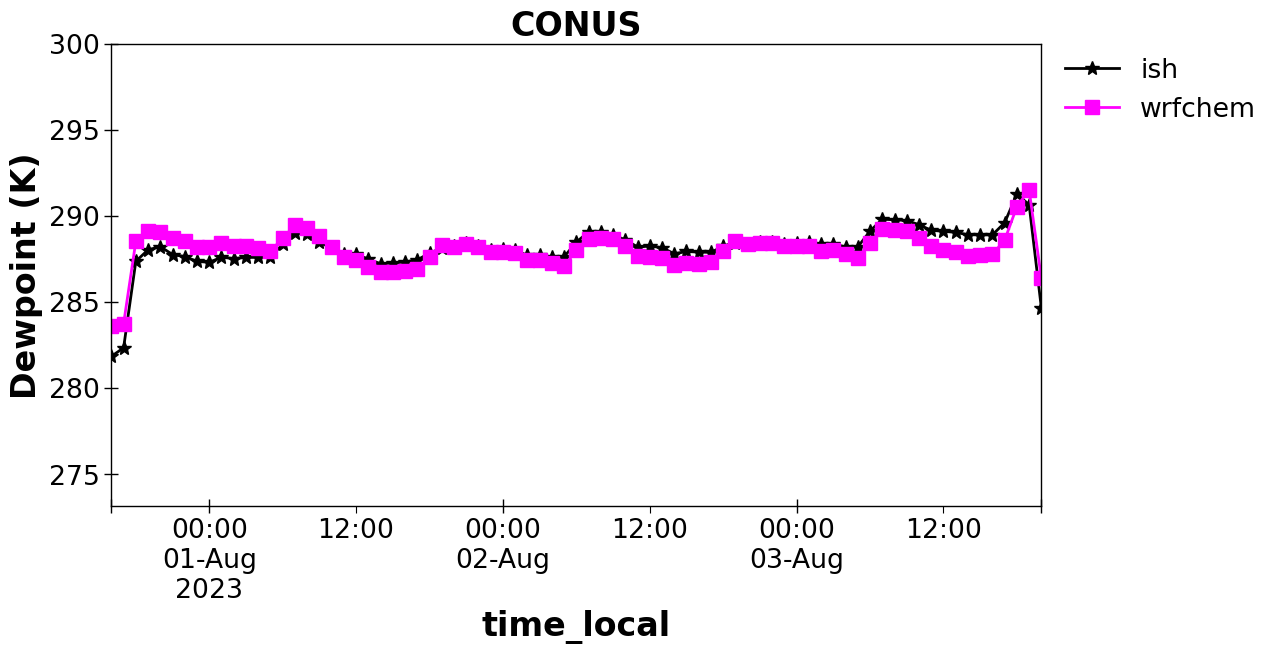

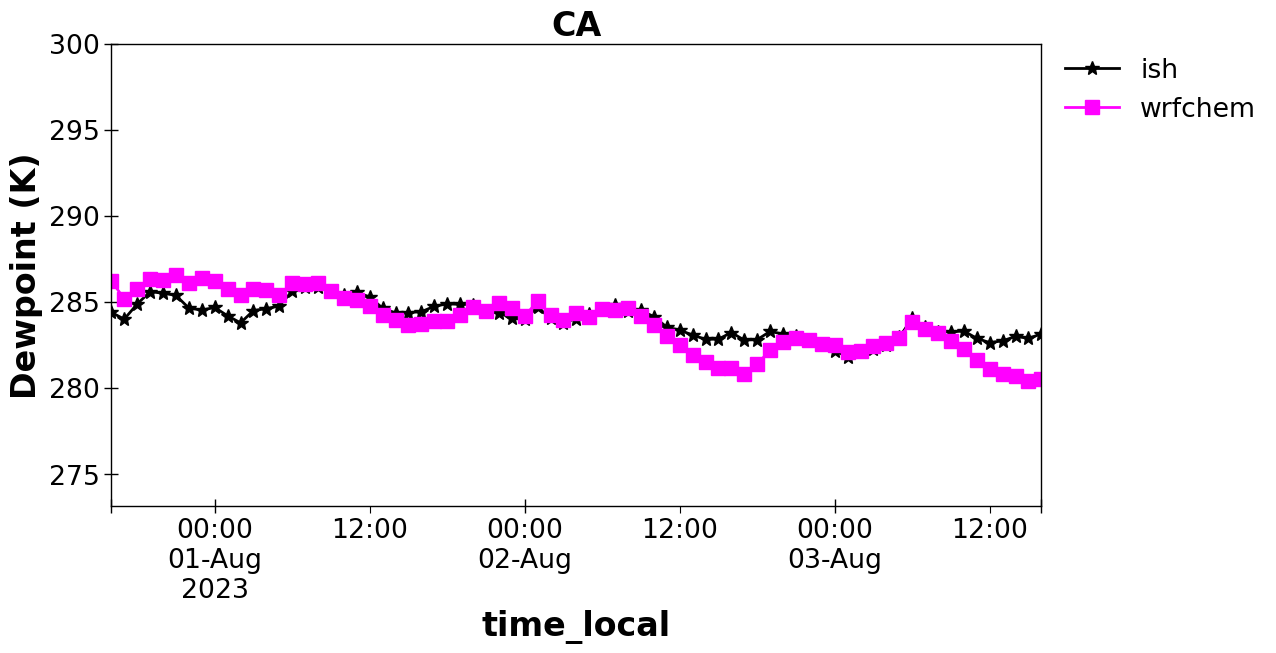

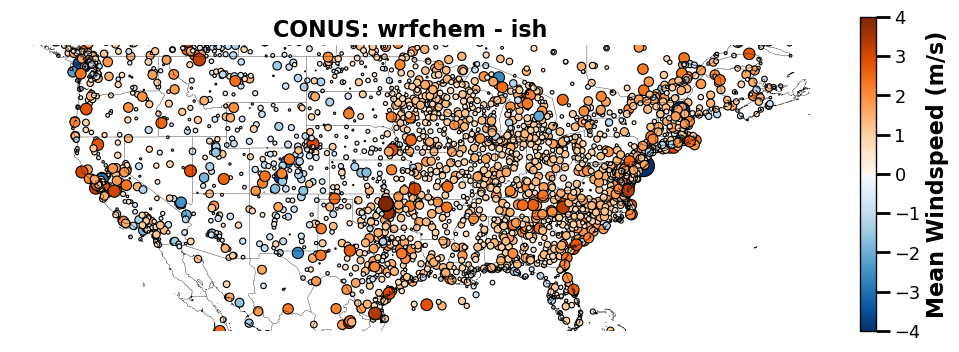

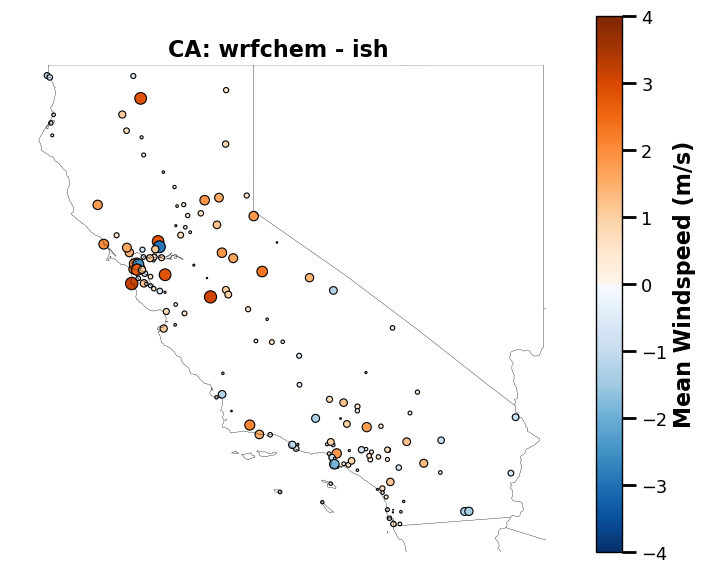

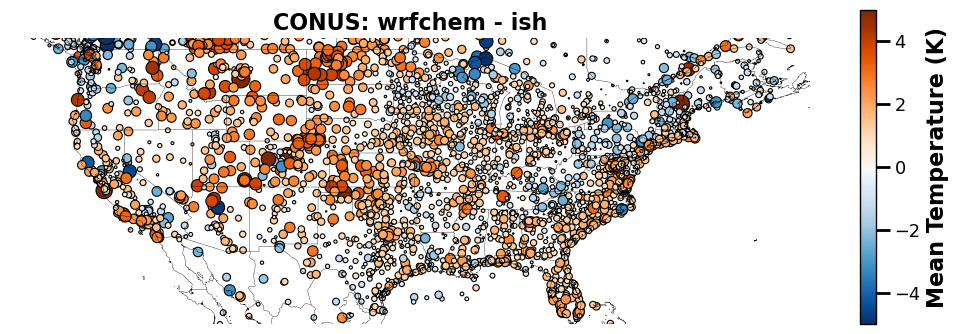

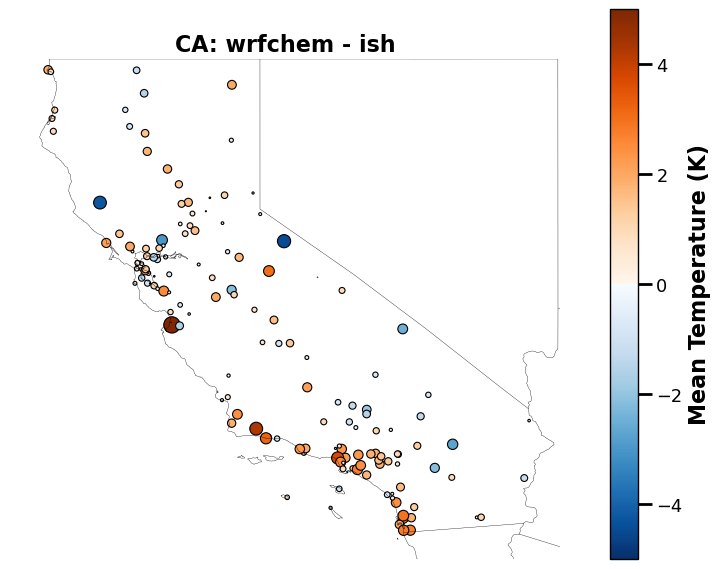

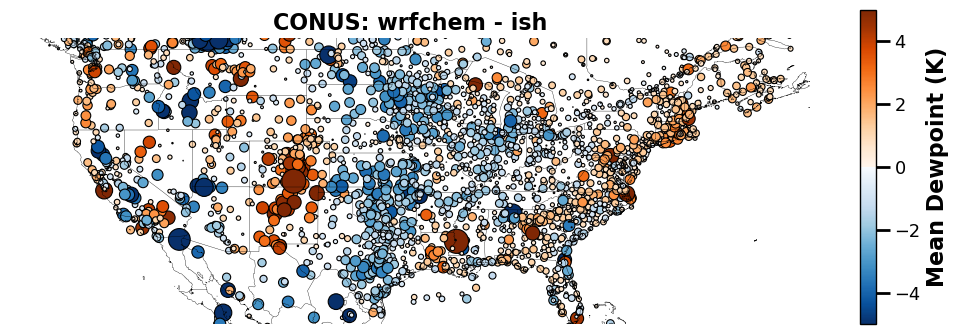

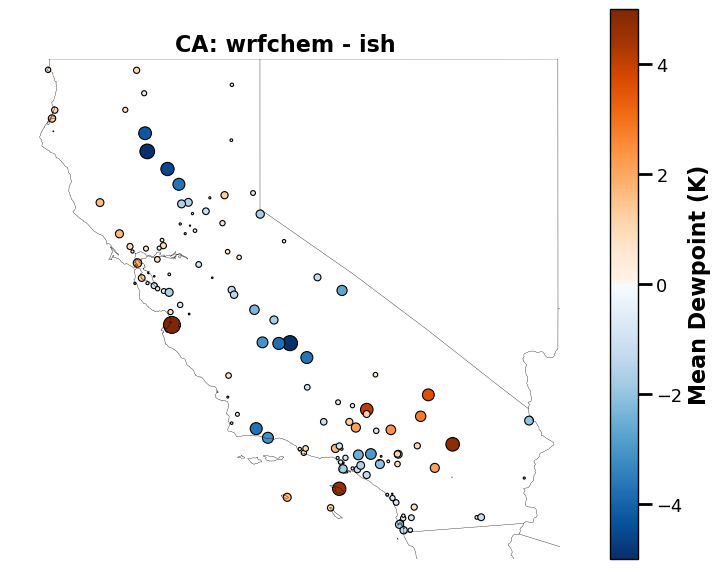

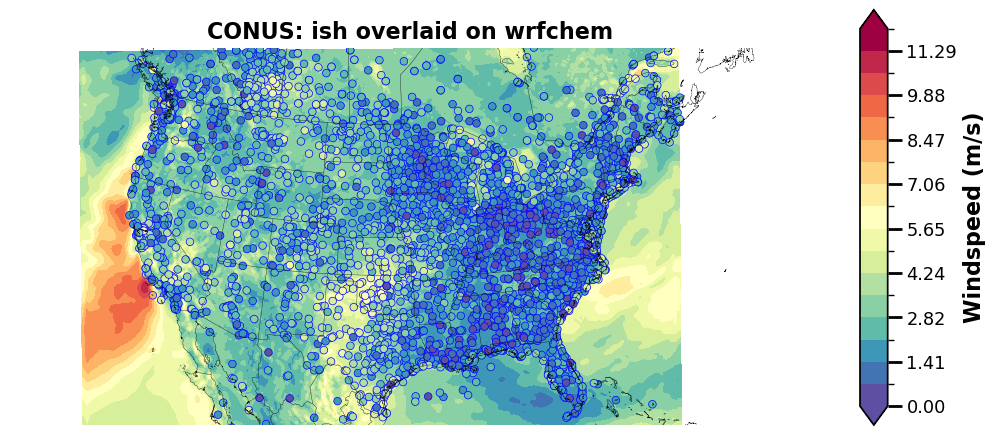

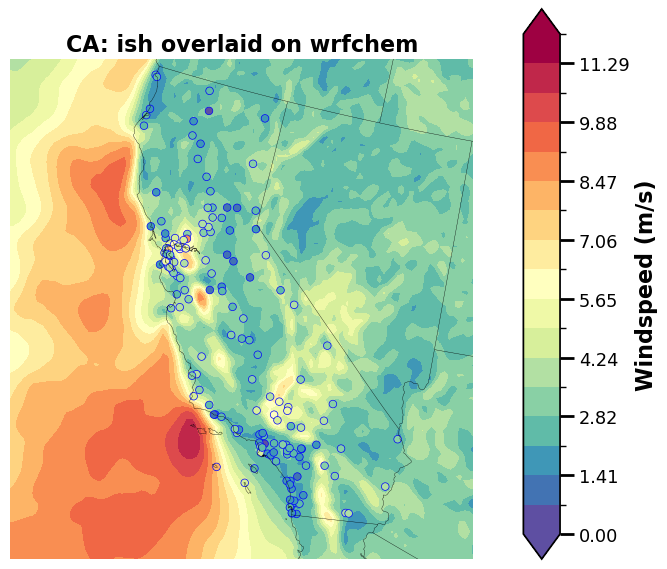

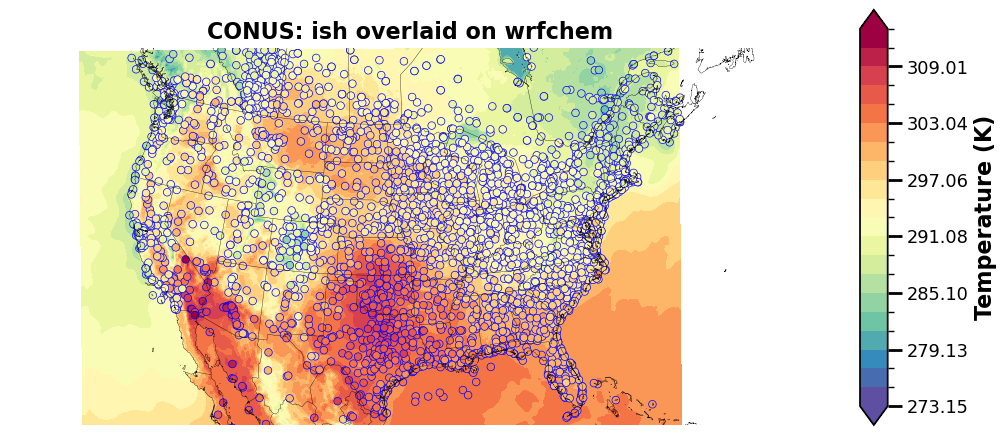

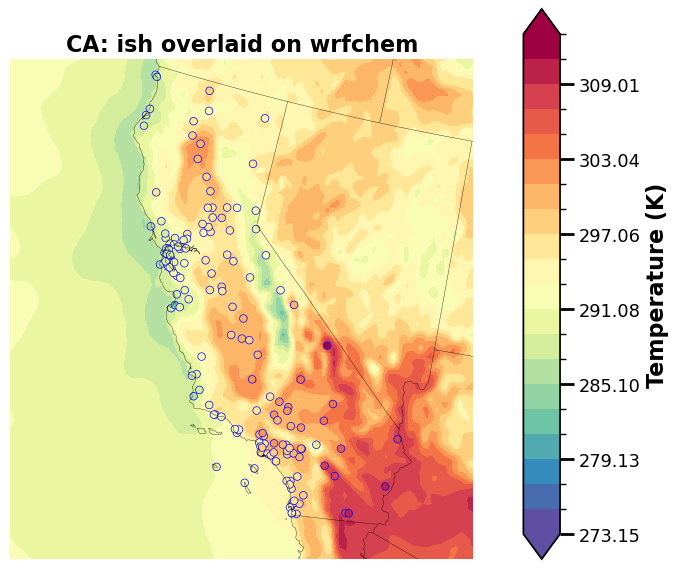

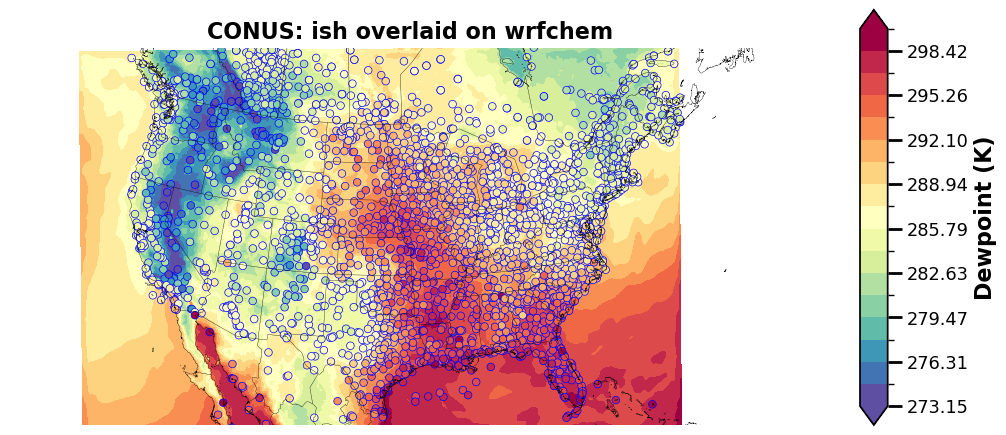

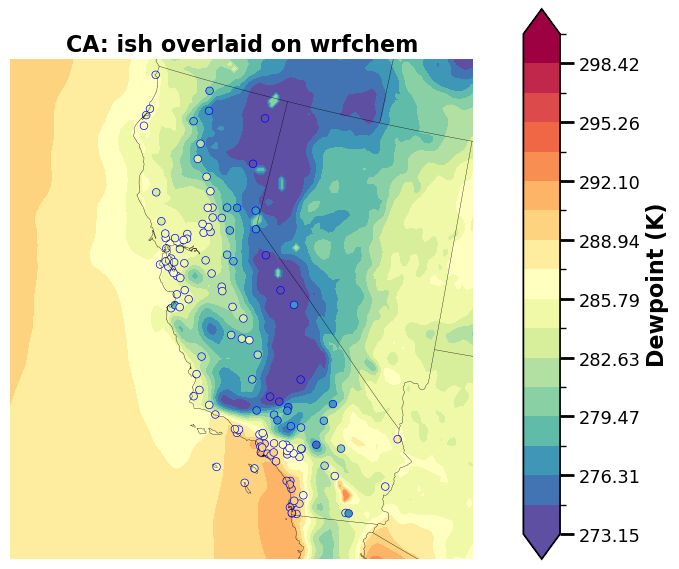

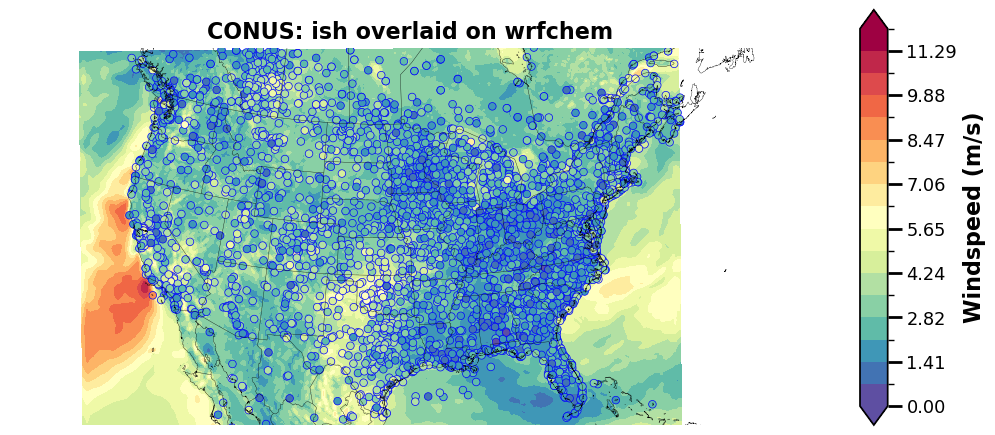

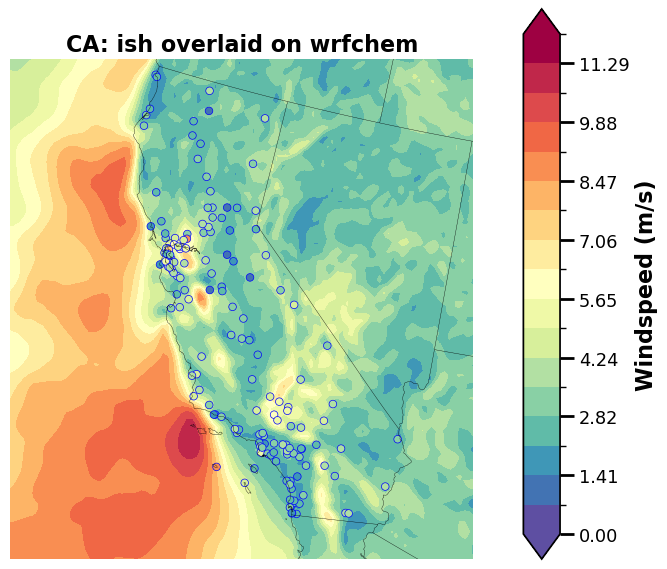

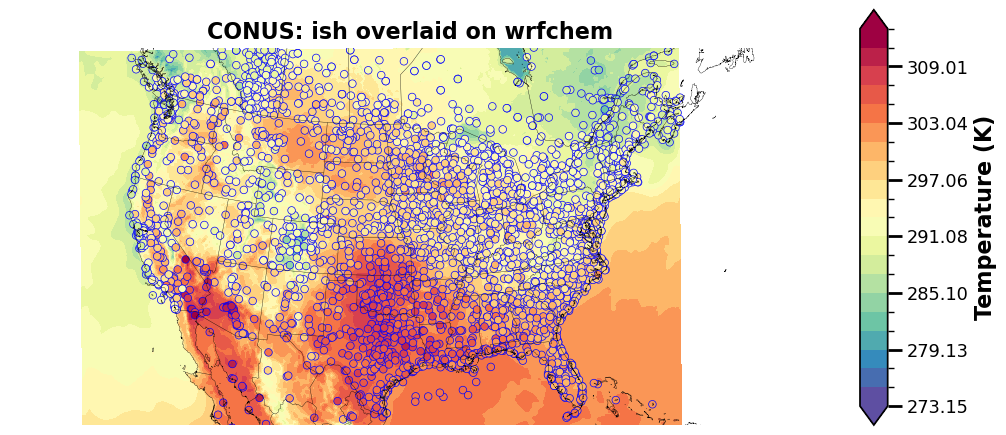

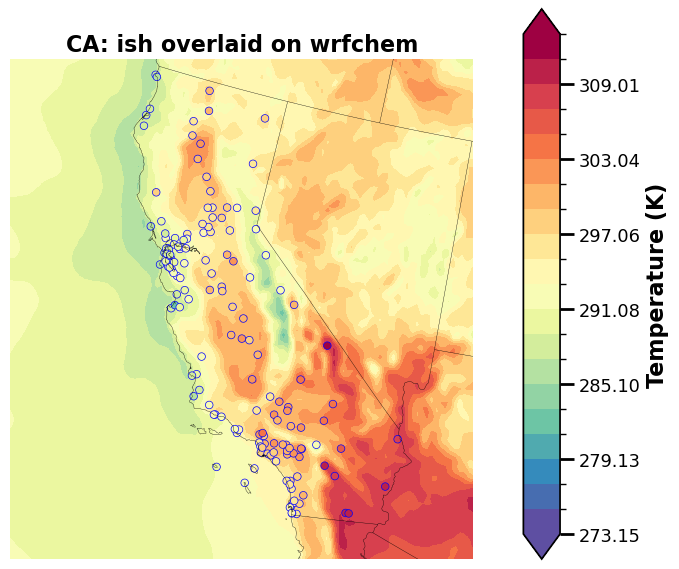

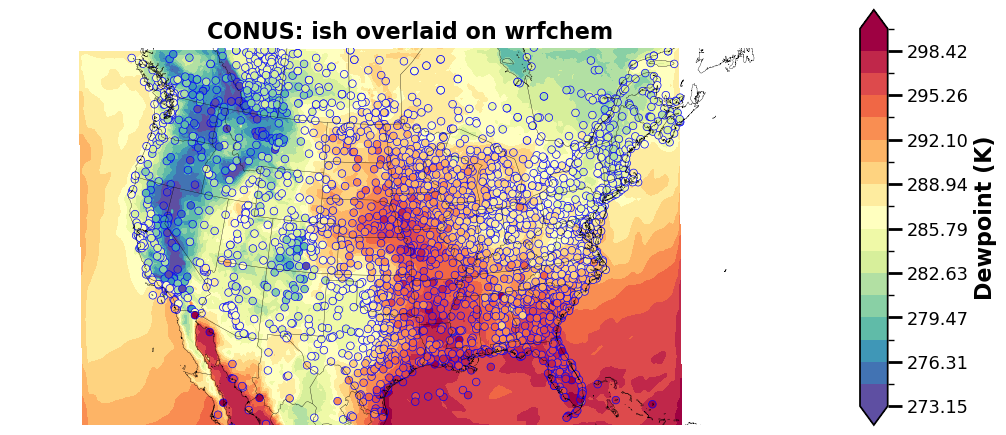

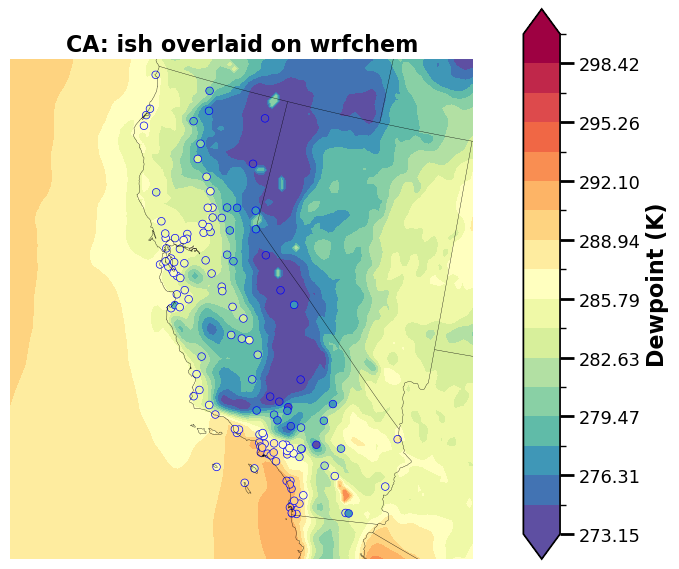

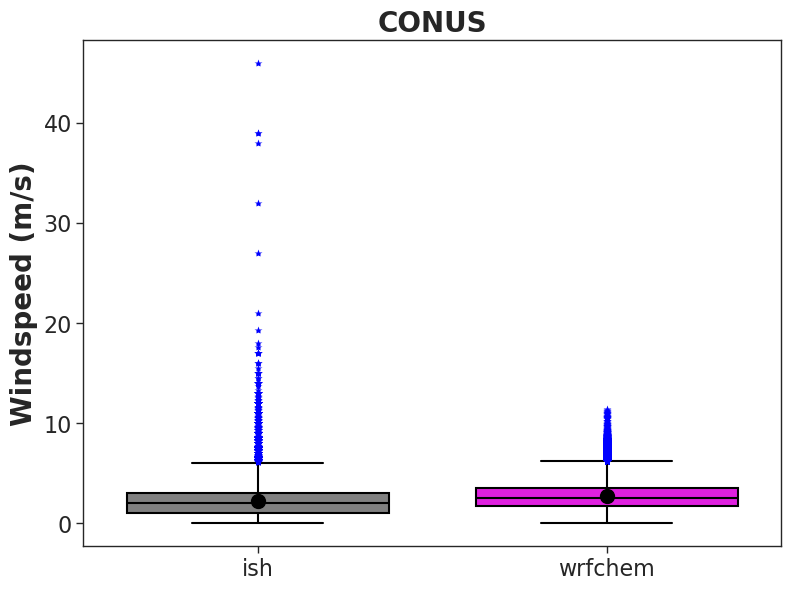

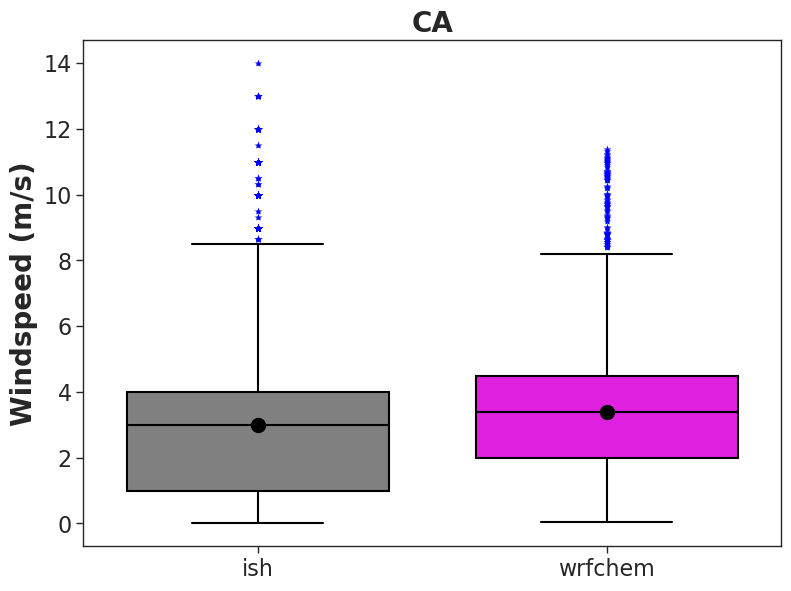

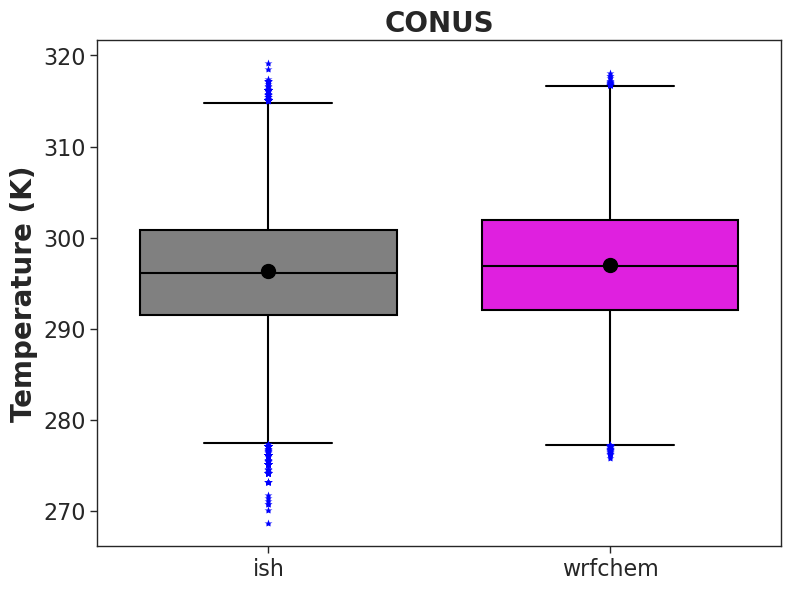

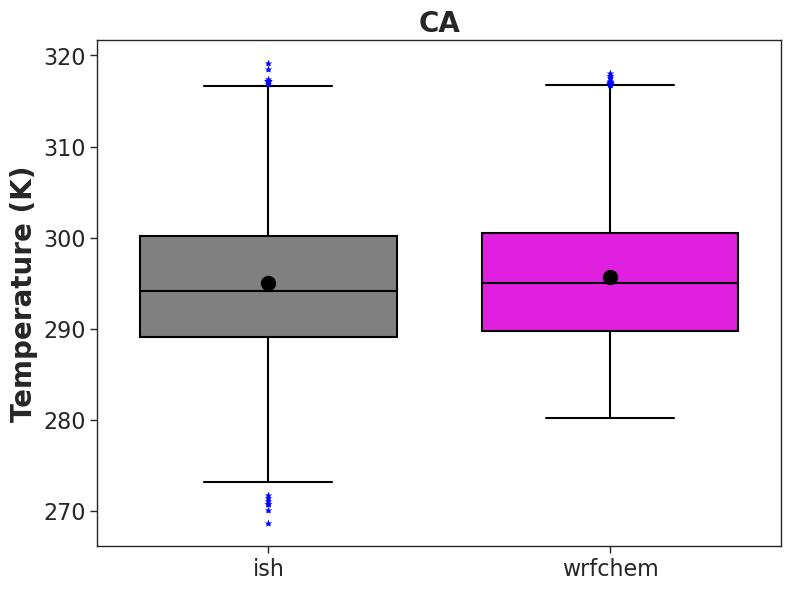

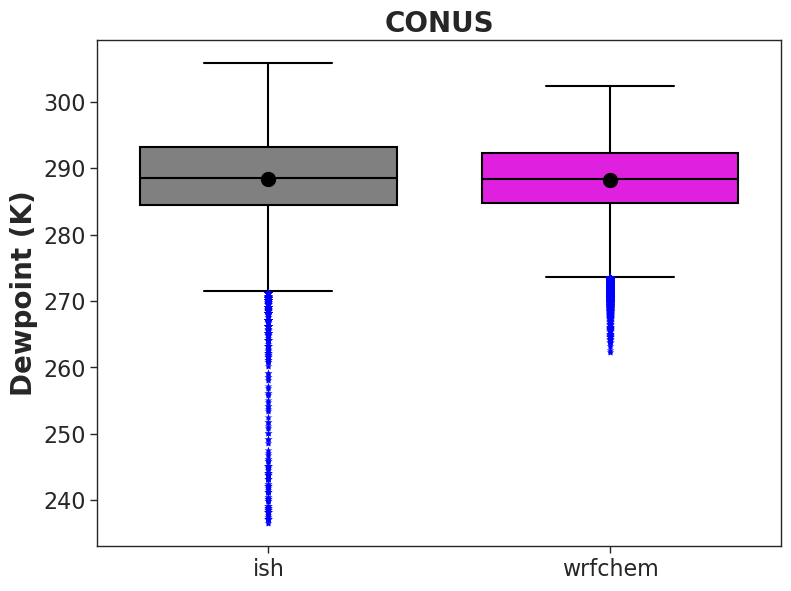

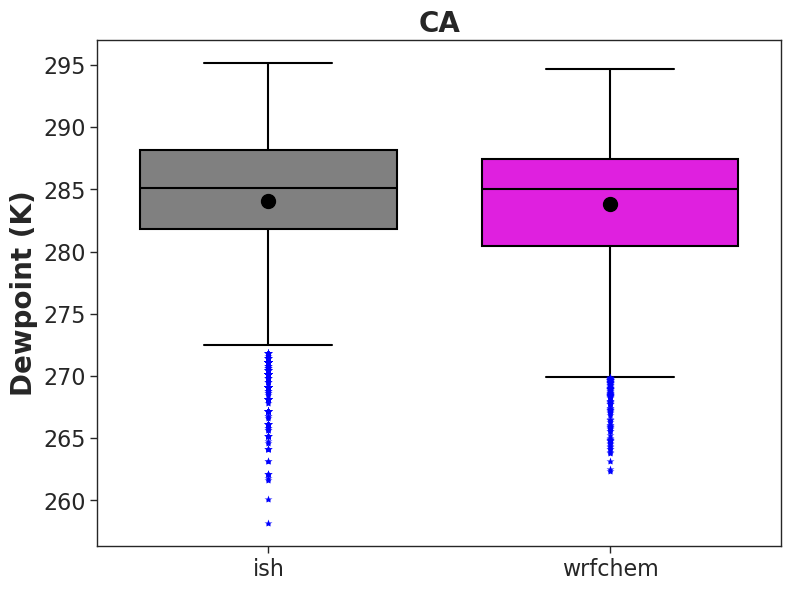

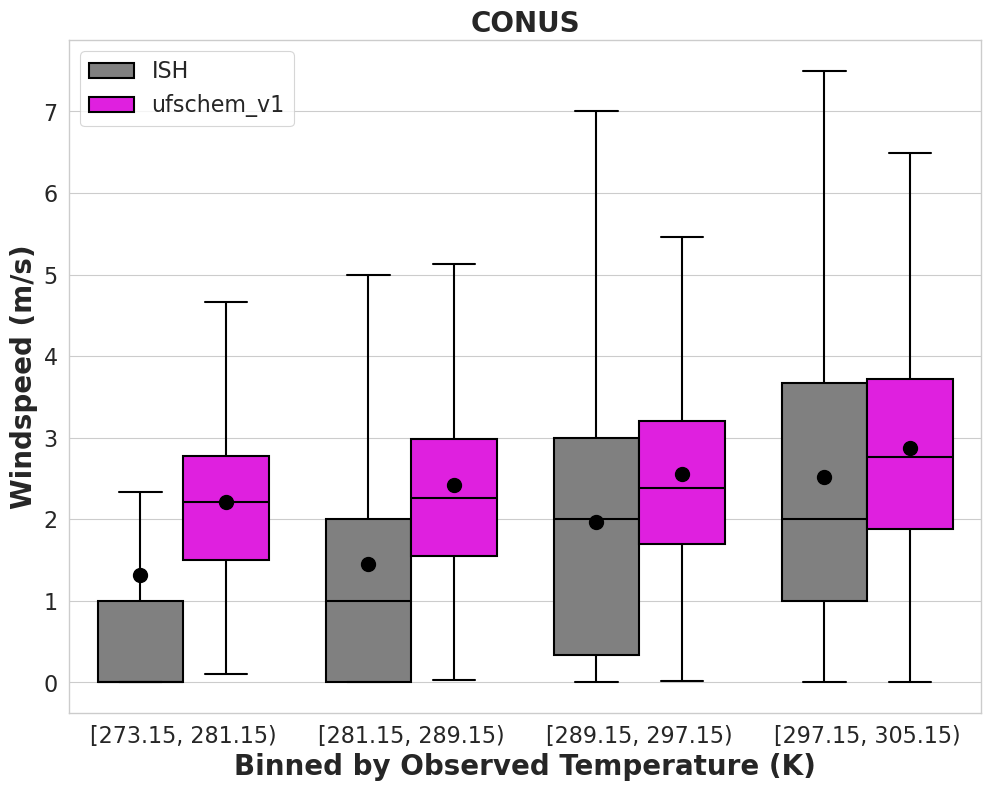

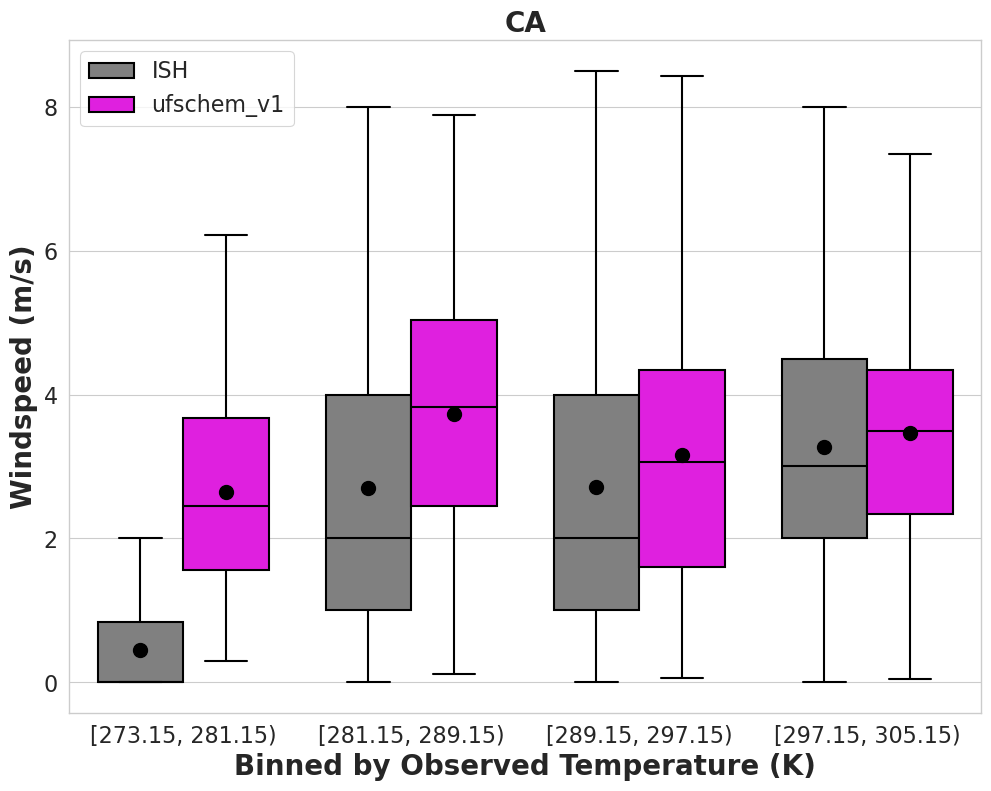

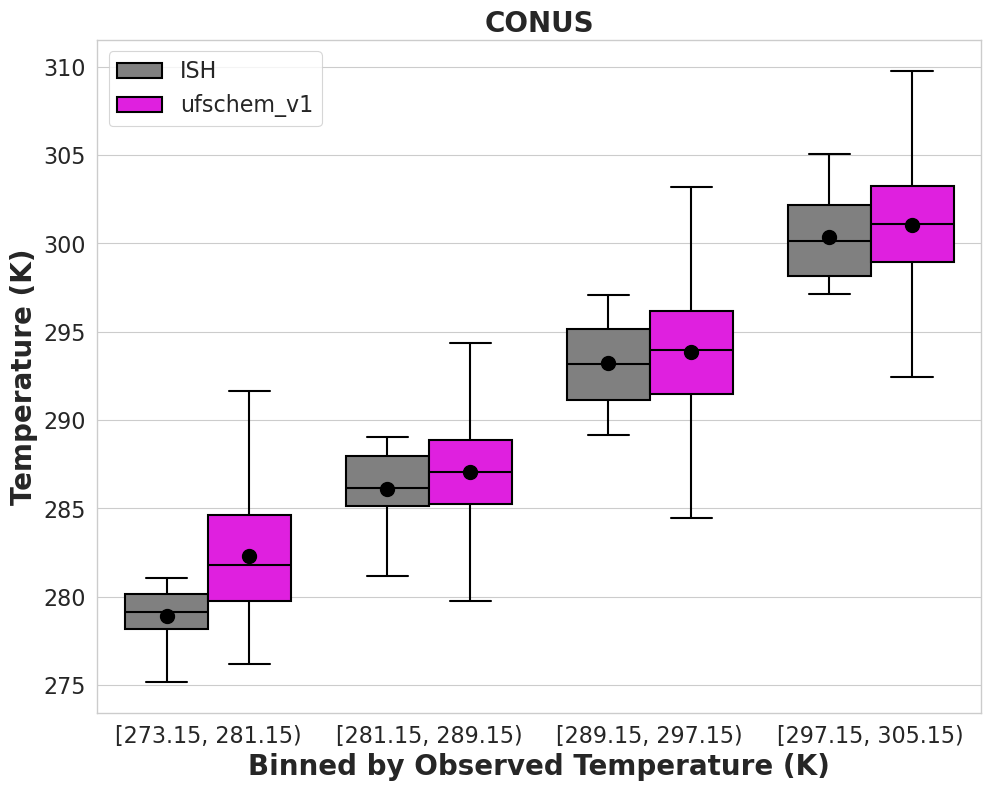

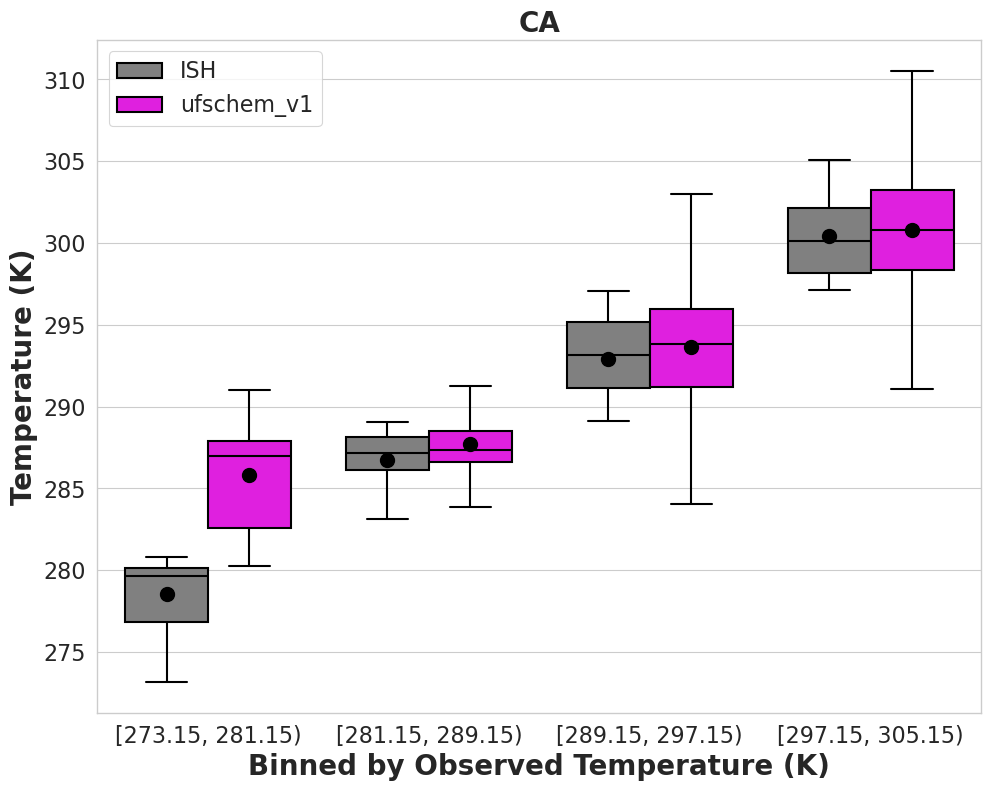

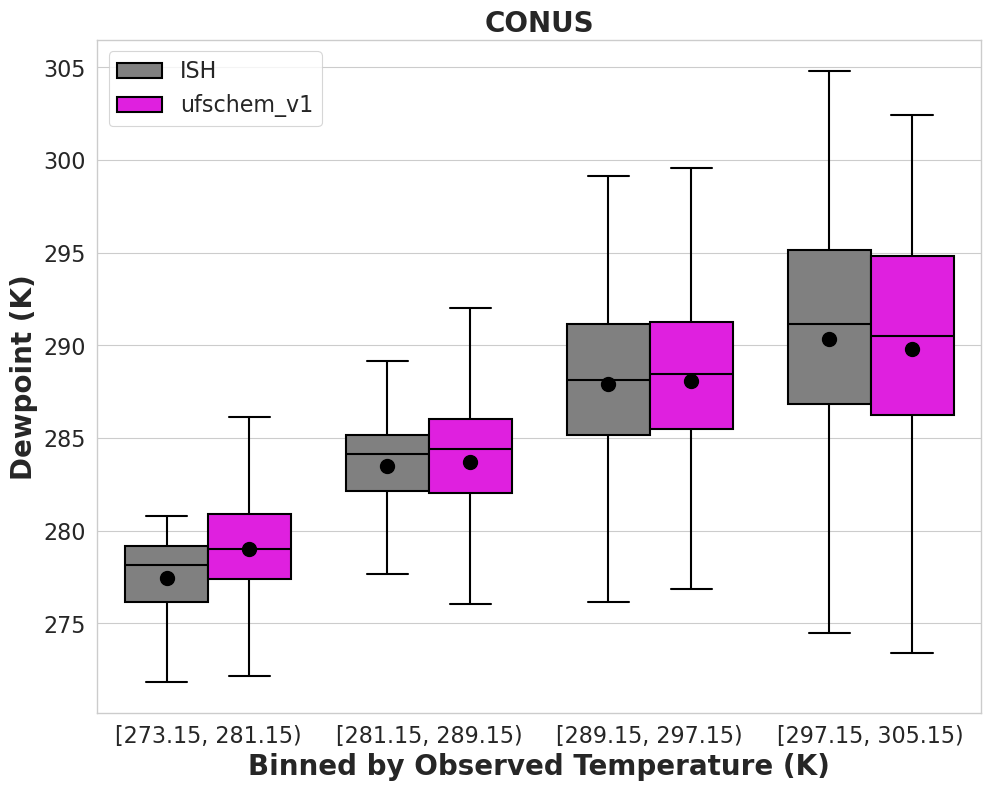

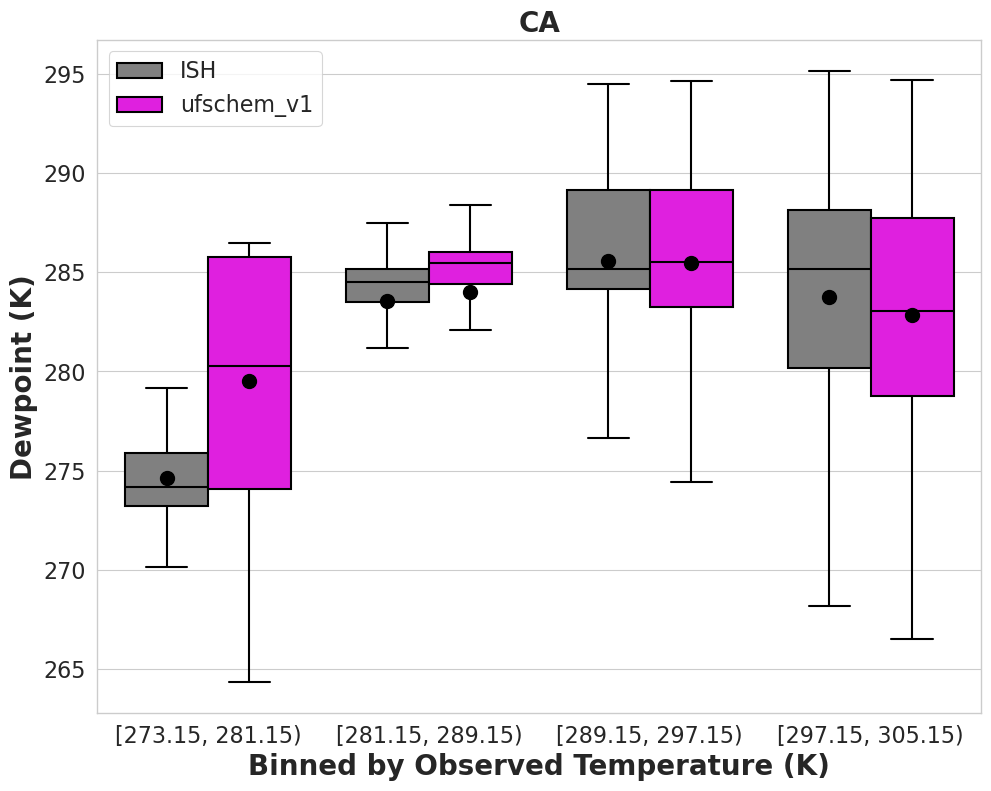

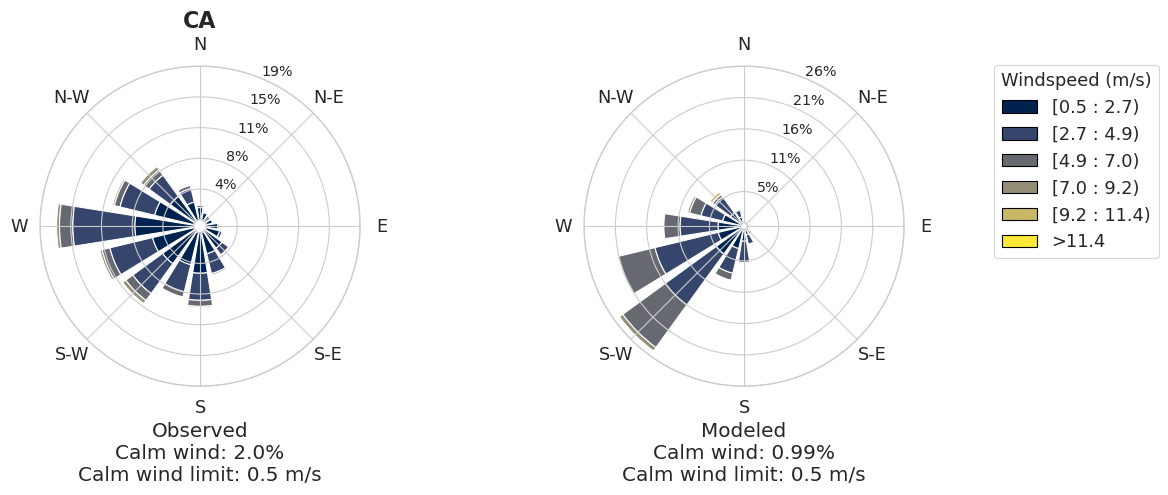

Saving rose plot to ./output/ish_wrfchem_restructure/plot_grp6.rose_plot.t.2023-08-01_00.2023-08-04_00.state.CA...


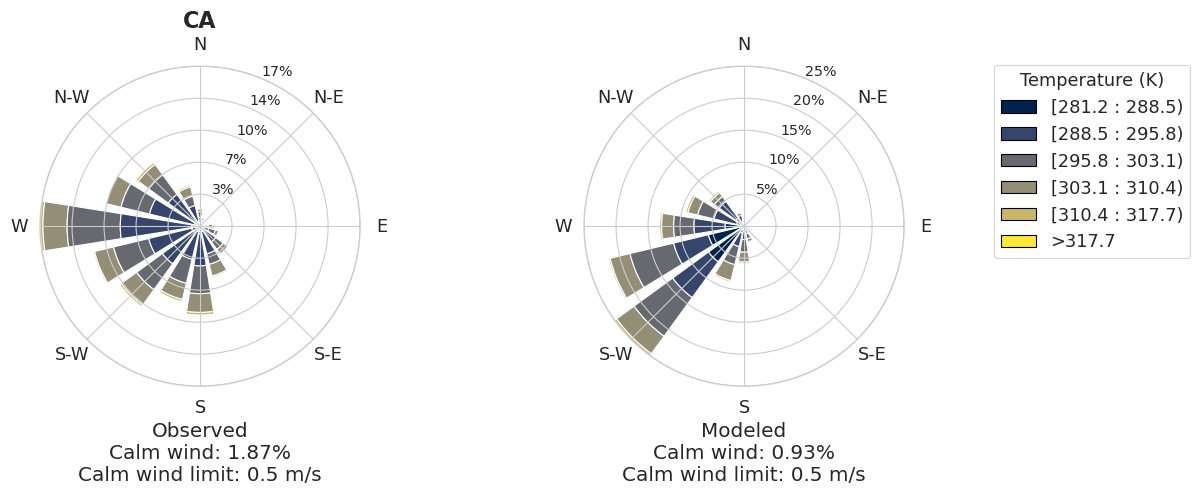

Saving rose plot to ./output/ish_wrfchem_restructure/plot_grp6.rose_plot.dpt.2023-08-01_00.2023-08-04_00.state.CA...


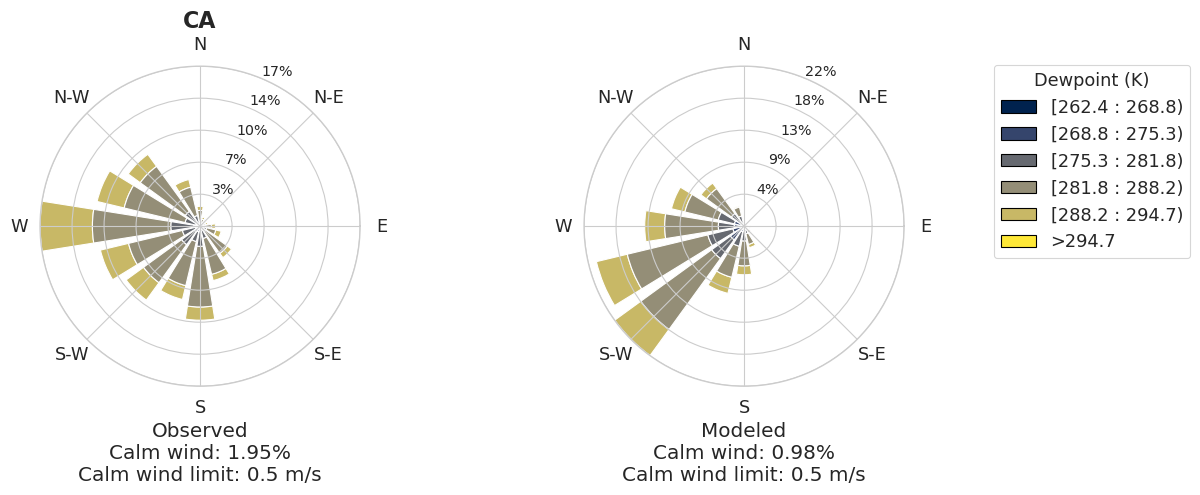

CPU times: user 5min 29s, sys: 1min 19s, total: 6min 48s
Wall time: 6min 50s


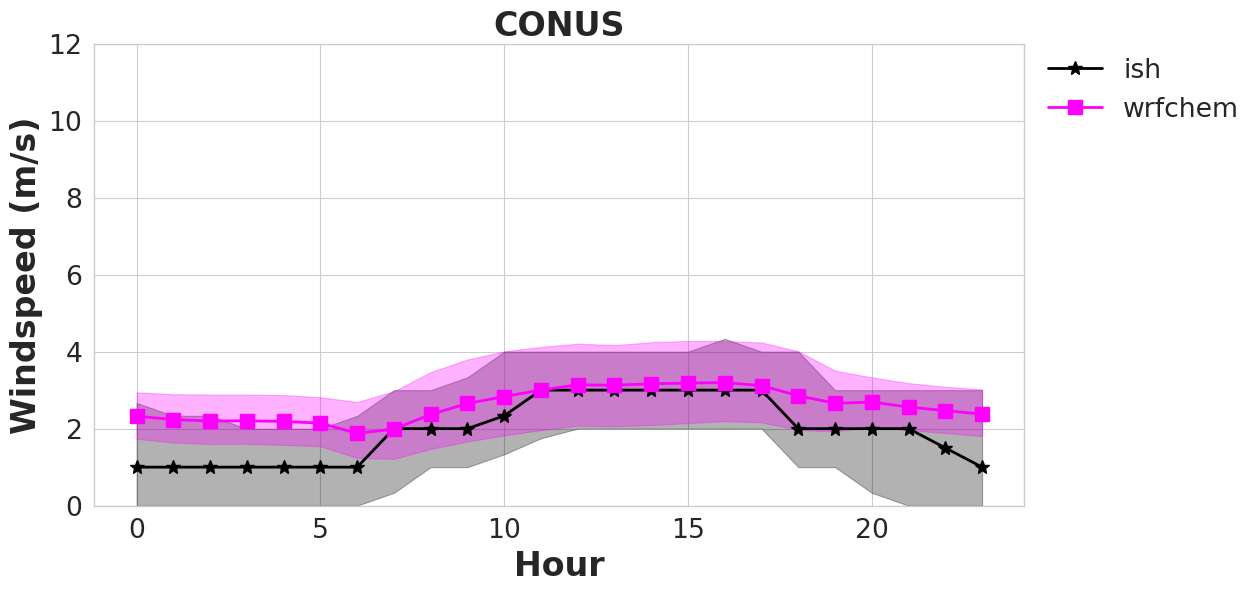

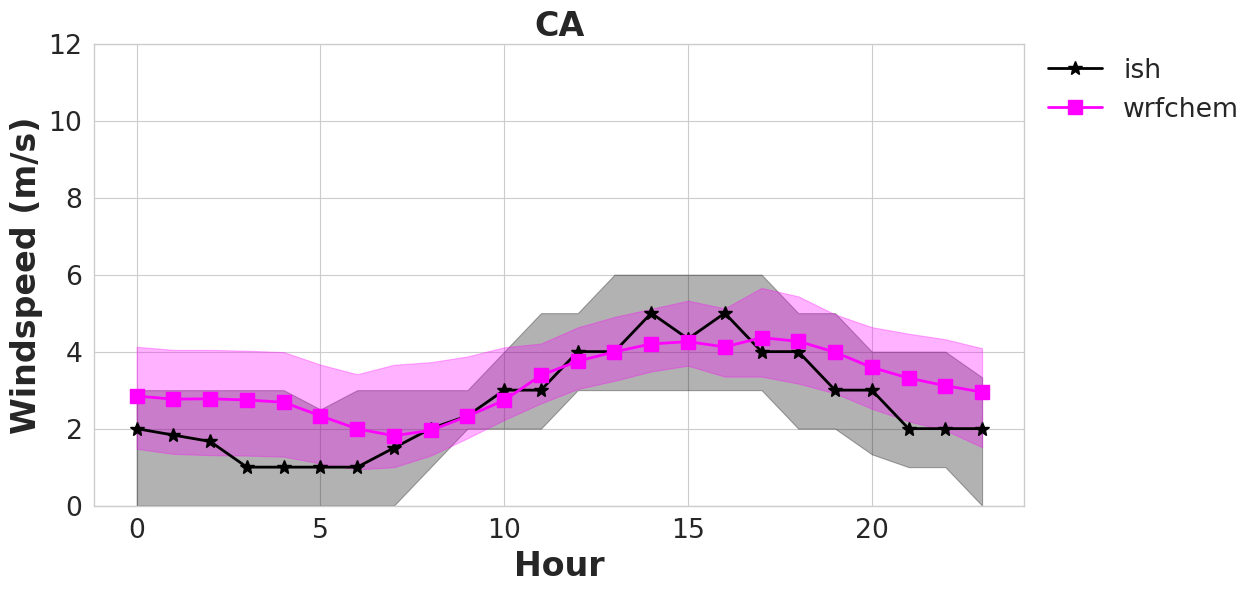

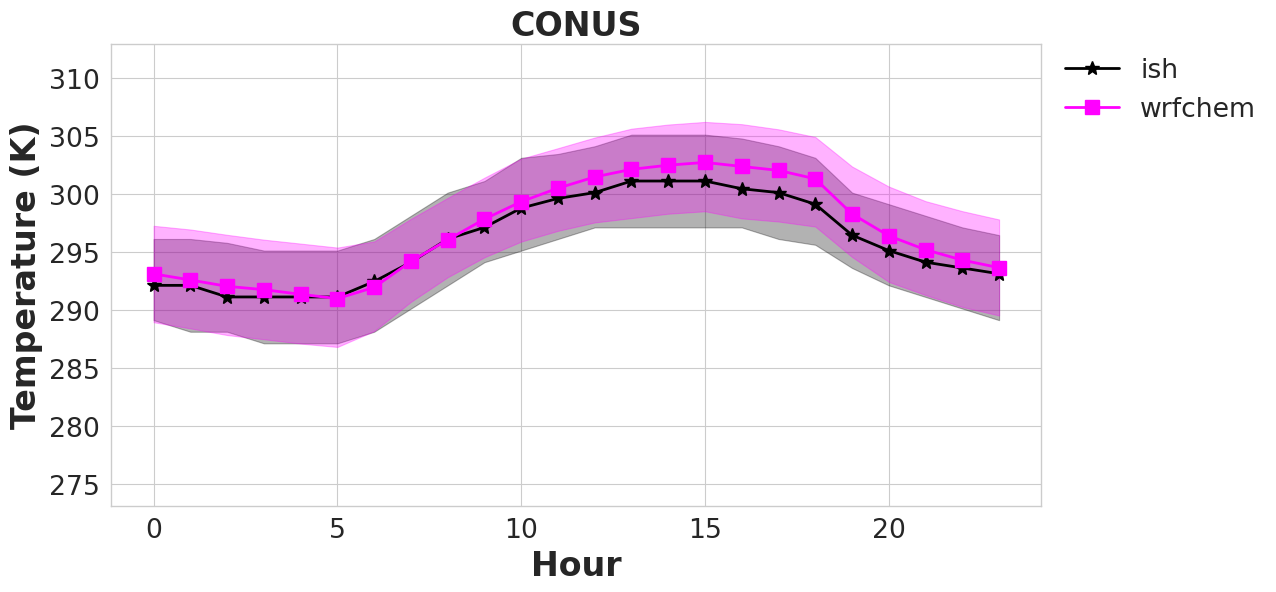

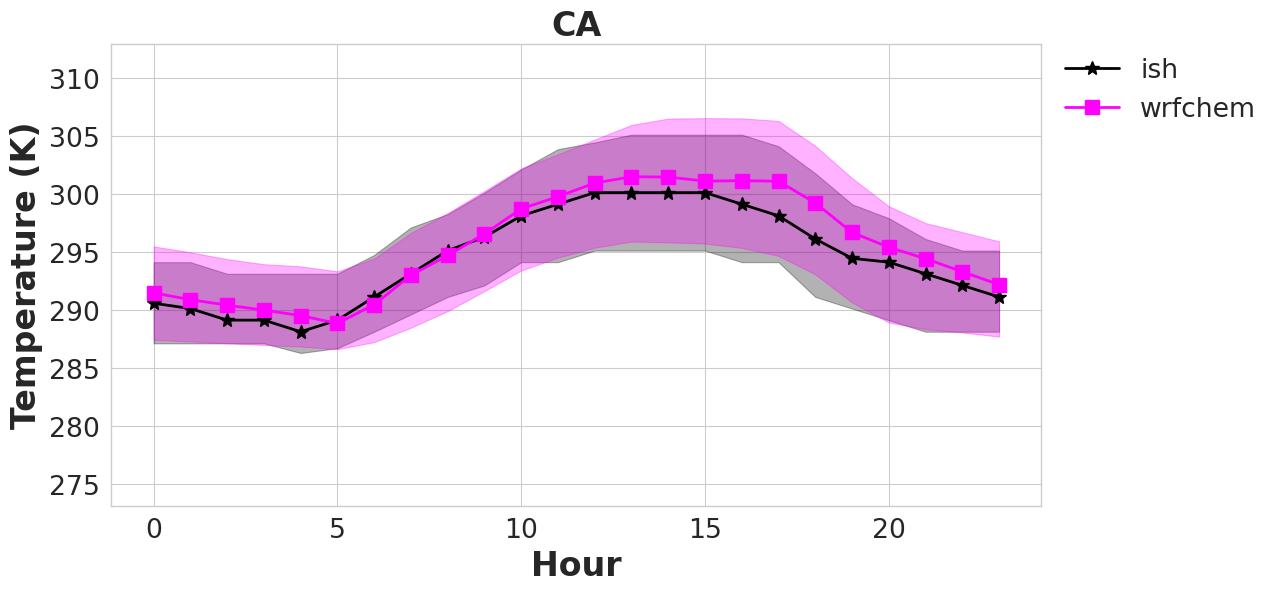

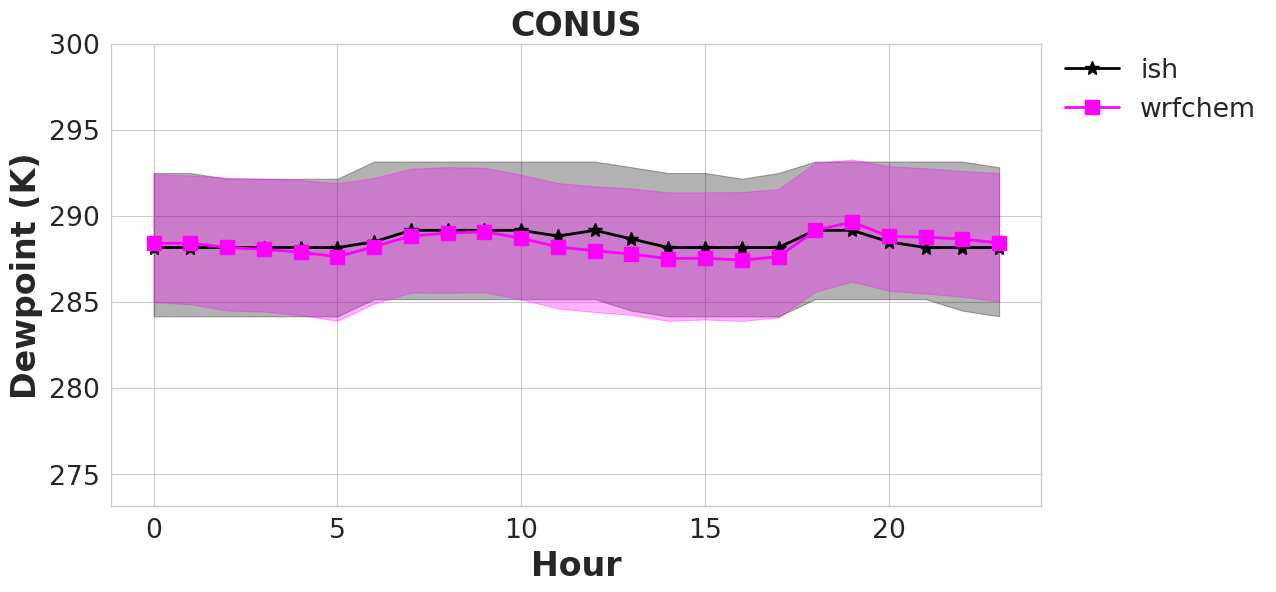

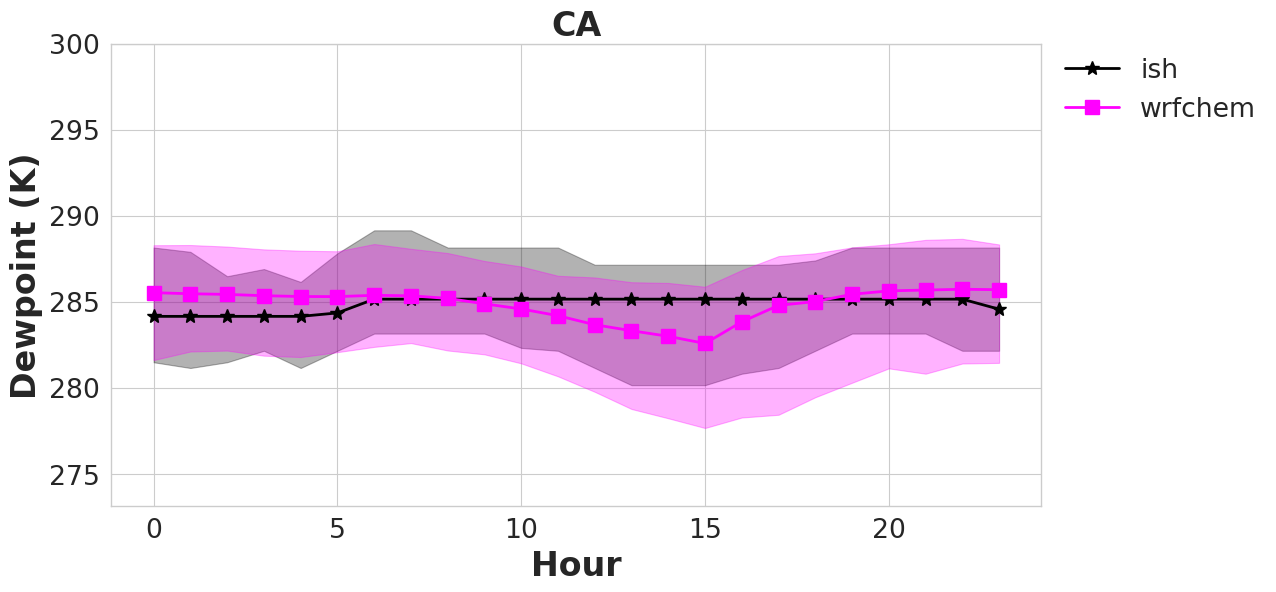

In [15]:
%%time

an.plotting()

CPU times: user 1min 38s, sys: 19.1 s, total: 1min 57s
Wall time: 1min 15s


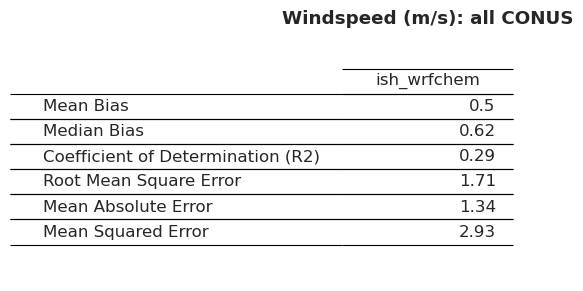

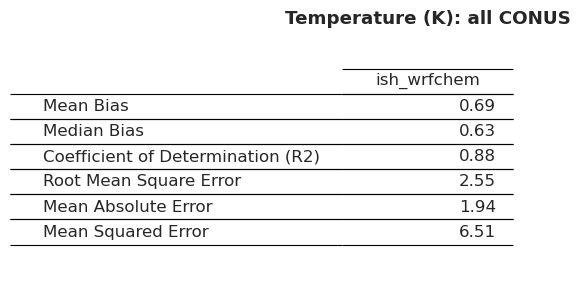

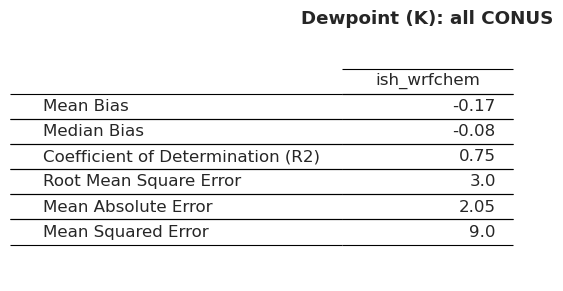

In [16]:
%%time

an.stats()

The stats routine has produced two files (one for each data variable).
This is one of them:
```{literalinclude} output/airnow_wrfchem/stats.OZONE.all.CONUS.2019-09-05_06.2019-09-06_06.csv
:caption:
```